In [1]:
from astropy.io import fits
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
import pandas as pd

from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.cosmology import Planck18 as cosmo

In [2]:
dp_cols = ['OII3726_dp', 'OII3729_dp',
        'Hbeta_dp',
        'OIII4959_dp', 'OIII5007_dp',
        'NII6548_dp', 'NII6583_dp', 'Halpha_dp', 
        'SII6716_dp', 'SII6731_dp']
dp_rank_cols = [f'{col[:-3]}_rank' for col in dp_cols]

In [3]:
DP = DP()
dps_df, model_1comp_dps, left_2comp_dps, right_2comp_dps = DP.extract_fits_data('./catalogs/0310_dps.fits')
cs_df, model_1comp_cs, left_2comp_cs, right_2comp_cs = DP.extract_fits_data('./catalogs/0310_nbcs.fits')

stellar_df = pd.read_csv('./catalogs/stellar_fits_catalog.csv')
dps_df = pd.merge(dps_df, stellar_df, on='TARGETID', how='left',validate='one_to_one')
cs_df = pd.merge(cs_df, stellar_df, on='TARGETID', how='left',validate='one_to_one')

dps_df.drop(columns=dp_rank_cols+['MORPHTYPE', 'p_value', 'BPT_1comp'], inplace=True)
cs_df.drop(columns=['MORPHTYPE', 'p_value', 'BPT_2comp', 'dv_r', 'dv_l', 'sigma_l', 'sigma_r'], inplace=True)

In [4]:
delta_dv = dps_df['dv_r'] - dps_df['dv_l']
resolution = c * 0.8 / (Halpha_rest*(1+dps_df['Z']))
sigma_r = np.sqrt(dps_df['sigma_r']**2 + resolution**2)
sigma_l = np.sqrt(dps_df['sigma_l']**2 + resolution**2)
dps_df['delta_dv'] = delta_dv
dps_df['width_ratio'] = sigma_l / sigma_r

# robust_dps = dps_df[(dps_df['BPT_2comp']!=512)&(dps_df['VD_SL']!=0)&(dps_df['LOGM']!=0)]
robust_dps = dps_df[(dps_df['BPT_2comp']!=512)&(dps_df['LOGM']!=0)]
robust_dps = robust_dps[(~robust_dps['width_ratio'].isnull())]
# robust_cs = cs_df[(cs_df['BPT_1comp']!=256)&(cs_df['VD_SL']!=0)&(cs_df['LOGM']!=0)]
robust_cs = cs_df[(cs_df['BPT_1comp']!=256)&(cs_df['LOGM']!=0)]

In [5]:
dAGN_dp = robust_dps[robust_dps['BPT_2comp']==32].copy()
print(len(dAGN_dp))
AGN_cs = robust_cs[robust_cs['BPT_1comp']==16].copy()
print(len(AGN_cs))

196
716


In [6]:
model_1comp_dps = model_1comp_dps[dAGN_dp.index]
left_2comp_dps = left_2comp_dps[dAGN_dp.index]
right_2comp_dps = right_2comp_dps[dAGN_dp.index]
print(len(model_1comp_dps), len(left_2comp_dps), len(right_2comp_dps))


model_1comp_cs = model_1comp_cs[AGN_cs.index]
print(len(model_1comp_cs))

196 196 196
716


In [7]:
dAGN_dp['flux_ratio'] = 0
for i in range(len(dAGN_dp)):
    lam = desi_wavelength/(1+dAGN_dp['Z'].iloc[i])
    left_shift = dAGN_dp['dv_l'].iloc[i] / c * OIII_rest[1]
    right_shift = dAGN_dp['dv_r'].iloc[i] / c * OIII_rest[1]

    left_flux = np.max(left_2comp_dps[i][(lam>(OIII_rest[1]+left_shift-2)) & (lam<(OIII_rest[1]+left_shift+2))])
    right_flux = np.max(right_2comp_dps[i][(lam>(OIII_rest[1]+right_shift-2)) & (lam<(OIII_rest[1]+right_shift+2))])

    if ((right_flux < 1) and (left_flux < 1)) or (dAGN_dp['OIII5007_dp'].iloc[i] is False):
        dAGN_dp['flux_ratio'].iloc[i] = np.nan
    else:
        dAGN_dp['flux_ratio'].iloc[i] = left_flux / right_flux



/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_38976/3528601165.py:13: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  dAGN_dp['flux_ratio'].iloc[i] = left_flux / right_flux
/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykerne

In [8]:
dAGN_dp = dAGN_dp[dAGN_dp['flux_ratio']!=0].copy()
print(len(dAGN_dp))

196


In [9]:
x = np.linspace(0.1, 10, 100)
y = 0.005-(0.96*np.log10(x))

In [10]:
from scipy import stats

data_x = np.log10(-dAGN_dp['dv_l']/dAGN_dp['dv_r'])
data_y = np.log10(dAGN_dp['flux_ratio'])

# remove NaN and inf values
valid_indices = np.isfinite(data_x) & np.isfinite(data_y) & (data_x > np.log10(0.1)) & (data_x < np.log10(10)) & (data_y > np.log10(0.1)) & (data_y < np.log10(10))
x_fit = data_x[valid_indices]
y_fit = data_y[valid_indices]

# linear fit
slope, intercept, r_value, p_value, std_err = stats.linregress(x_fit, y_fit)

print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"R-squared: {r_value**2}")

fit_x_range = np.linspace(0.1, 10, 100)
fit_y_values = slope * np.log10(fit_x_range) + intercept
print(p_value)


Slope: -0.43366012420783856
Intercept: -0.041344637563786896
R-squared: 0.33978791674473696
1.6872488650162316e-18


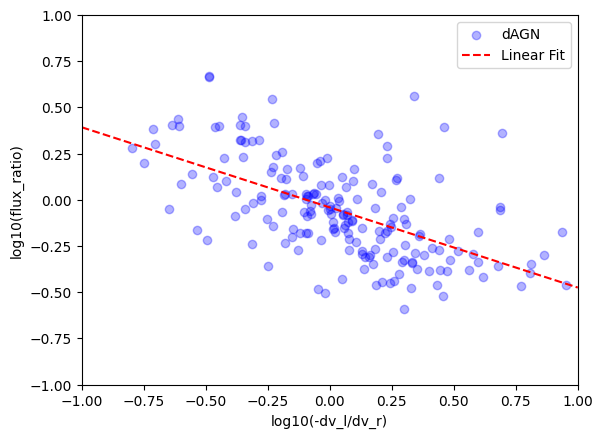

In [11]:
plt.scatter(data_x, data_y, alpha=0.3, color='blue', label='dAGN')
plt.plot(np.log10(fit_x_range), fit_y_values, color='r', linestyle='--', label='Linear Fit')
plt.xlabel('log10(-dv_l/dv_r)')
plt.ylabel('log10(flux_ratio)')
plt.xlim(np.log10(0.1), np.log10(10))
plt.ylim(np.log10(0.1), np.log10(10))
plt.legend()
plt.show()

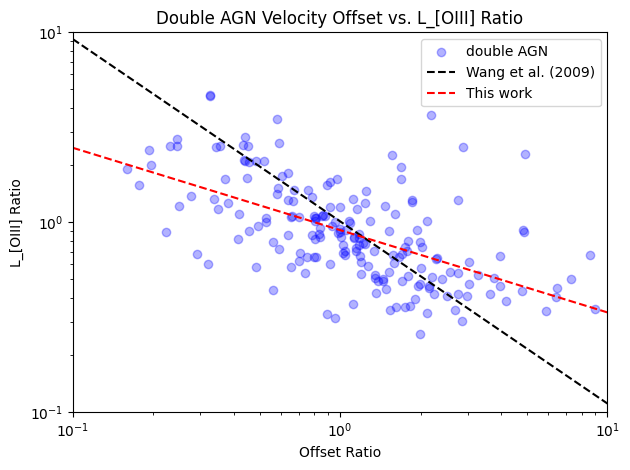

In [12]:
plt.scatter(-dAGN_dp['dv_l']/dAGN_dp['dv_r'], dAGN_dp['flux_ratio'], alpha=0.3, color='blue', label='double AGN')
plt.plot(x, 10**y, color='k', label='Wang et al. (2009)', linestyle='--')
plt.plot(fit_x_range, 10**fit_y_values, color='r', linestyle='--', label='This work')
plt.xscale('log')
plt.yscale('log')
plt.xlim(left=0.1, right=10)
plt.ylim(bottom=0.1, top=10)
plt.xlabel('Offset Ratio')
plt.ylabel('L_[OIII] Ratio')
plt.title('Double AGN Velocity Offset vs. L_[OIII] Ratio')
plt.legend()
plt.tight_layout()
plt.savefig('./figures/Feb25/dAGN_flux_ratio.png')
plt.show()